# 📦 Environment Setup

In [12]:
import os
print("Current working directory:", os.getcwd())


Current working directory: c:\Users\User\prp_model\prp_model


In [2]:
!git clone https://github.com/acesmeci/prp_model.git
%cd prp_model

c:\Users\User\prp_model\prp_model


fatal: destination path 'prp_model' already exists and is not an empty directory.
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
!git remote set-url origin https://github.com/acesmeci/prp_model.git


In [4]:
# IMPORTS
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Module reloader
import importlib
import prp_simulator
importlib.reload(prp_simulator)


<module 'prp_simulator' from '/content/drive/MyDrive/Thesis/PRP_Model/prp_model/prp_simulator.py'>

# 🧠 Train TaskNetwork

In [11]:
from prp_model.task_generator import generate_task_patterns
from prp_model.nn_wrapper import TaskNetworkWrapper

# Generate single-task training data
inp, task, target, _ = generate_task_patterns(
    N_pathways=3, N_features=3, samples_per_task=5,
    relevant_tasks=[1, 2, 4, 5, 9], seed=0
)

# Create and train the network
net = TaskNetworkWrapper(hidden_size=60)
net.train_online(inp, task, target, n_epochs=200)


ModuleNotFoundError: No module named 'prp_model'

# 🎮 Simulate Single PRP Trial (LCA)

In [ ]:
from prp_model.prp_simulator import run_prp_trial
from prp_model.task_generator import generate_task_patterns

input_sgl, tasks_sgl, _, _ = generate_task_patterns(
    N_pathways=3, N_features=3, samples_per_task=1,
    relevant_tasks=[1, 2], seed=42
)

stim_a, stim_b = input_sgl[0], input_sgl[1]
task_a, task_b = tasks_sgl[0], tasks_sgl[1]

rt_a, acc_a, rt_b, acc_b, outputs = run_prp_trial(
    task_net=net,
    input_a=stim_a,
    input_b=stim_b,
    task_a=task_a,
    task_b=task_b,
    soa=3,
    threshold=1.0,
    tau_net=1.0,
    tau_task=1.0,
    persistence=0.8
)

print(f"RT A: {rt_a}, Accuracy A: {acc_a}")
print(f"RT B: {rt_b}, Accuracy B: {acc_b}")


RT A: 1.45, Accuracy A: False
RT B: 1.6500000000000001, Accuracy B: True


# 📈 PRP Curve (LCA-Based Simulation)

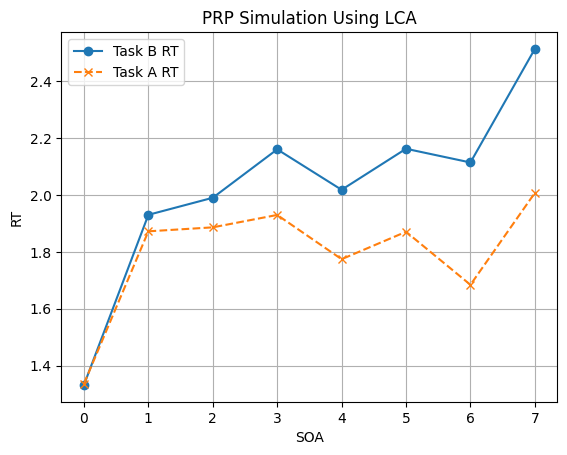

In [ ]:
from prp_model.prp_simulator import sweep_soa

def simple_trial_generator():
    input_sgl, tasks_sgl, _, _ = generate_task_patterns(
        N_pathways=3, N_features=3, samples_per_task=1,
        relevant_tasks=[1, 2], seed=None
    )
    return input_sgl[0], input_sgl[1], tasks_sgl[0], tasks_sgl[1]

results_lca = sweep_soa(
    task_net=net,
    trial_generator=simple_trial_generator,
    soa_values=list(range(0, 8)),
    n_trials_per_soa=50,
    threshold=1.0,
    tau_net=1.0,
    tau_task=1.0,
    persistence=0.8,
    verbose=False
)

# Plot RTs
plt.plot(results_lca["soa"], results_lca["rt_b"], label="Task B RT", marker='o')
plt.plot(results_lca["soa"], results_lca["rt_a"], label="Task A RT", marker='x', linestyle='--')
plt.xlabel("SOA")
plt.ylabel("RT")
plt.title("PRP Simulation Using LCA")
plt.grid(True)
plt.legend()
plt.show()

# 📉 Error Rates Across SOA

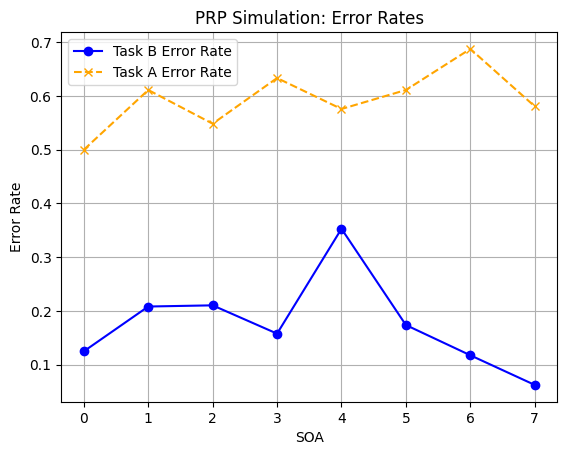

In [ ]:
# Compare error rates of Task A vs. Task B

err_a = [1 - a if not np.isnan(a) else np.nan for a in results_lca["acc_a"]]
err_b = [1 - b if not np.isnan(b) else np.nan for b in results_lca["acc_b"]]

plt.plot(results_lca["soa"], err_b, marker='o', label="Task B Error Rate", color="blue")
plt.plot(results_lca["soa"], err_a, marker='x', linestyle='--', label="Task A Error Rate", color="orange")
plt.xlabel("SOA")
plt.ylabel("Error Rate")
plt.title("PRP Simulation: Error Rates")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# Multitask generator test cell
from prp_model.multitask_generator import generate_multitask_patterns

# Parameters
N_pathways = 3
N_features = 3
samples_per_task = 5
relevant_tasks = [1, 2, 4, 5, 9]  # same as single-task

input_multi, tasks_multi, train_multi, meta = generate_multitask_patterns(
    N_pathways=N_pathways,
    N_features=N_features,
    samples_per_task=samples_per_task,
    relevant_tasks=relevant_tasks
)

print("Multi-task input shape:", input_multi.shape)
print("Multi-task task shape:", tasks_multi.shape)
print("Multi-task output shape:", train_multi.shape)
print("Number of multitask combinations:", len(meta["taskCombs"]))


Multi-task input shape: (30, 9)
Multi-task task shape: (30, 9)
Multi-task output shape: (30, 9)
Number of multitask combinations: 6


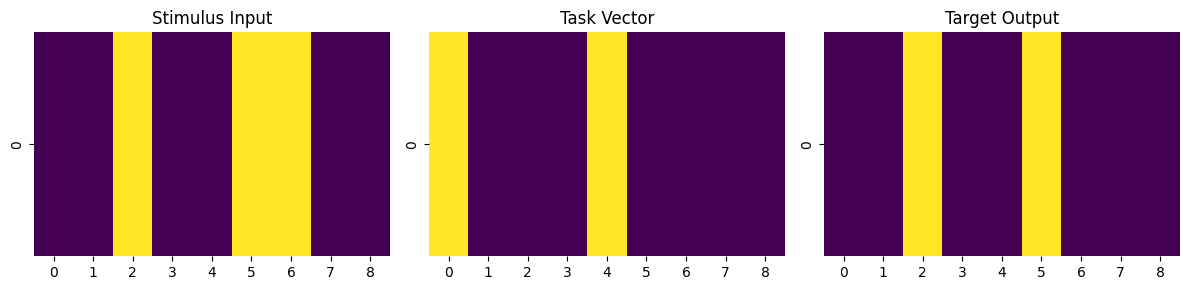

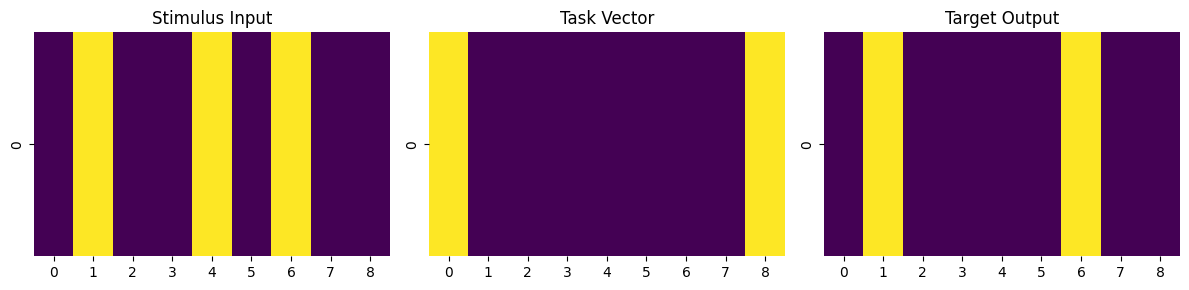

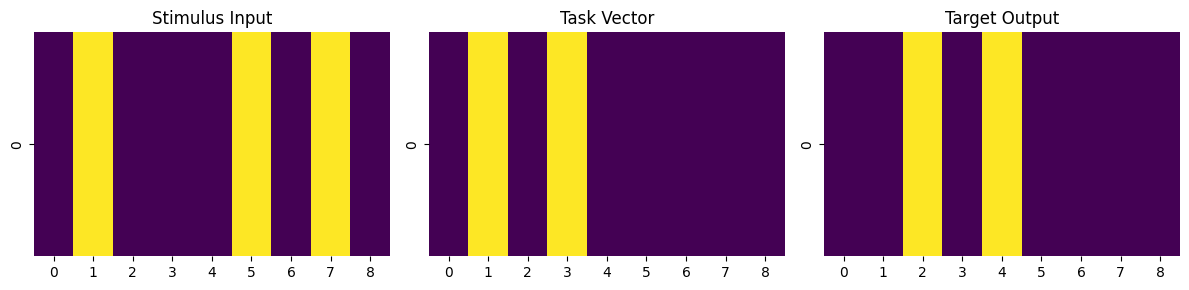

In [ ]:
# Inspect result of multitask generator

def plot_pattern(index):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))

    sns.heatmap(input_multi[index:index+1], cmap="viridis", ax=axes[0], cbar=False)
    axes[0].set_title("Stimulus Input")

    sns.heatmap(tasks_multi[index:index+1], cmap="viridis", ax=axes[1], cbar=False)
    axes[1].set_title("Task Vector")

    sns.heatmap(train_multi[index:index+1], cmap="viridis", ax=axes[2], cbar=False)
    axes[2].set_title("Target Output")

    plt.tight_layout()
    plt.show()

# Plot a few
plot_pattern(0)
plot_pattern(5)
plot_pattern(10)


In [ ]:
from prp_modeltraining_utils import train_with_optional_multitask

net = TaskNetworkWrapper(hidden_size=60)
train_with_optional_multitask(net, pretrain_multitask=True)


Epoch 000 | Loss: 0.2209 | Accuracy: 0.15
Epoch 010 | Loss: 0.0553 | Accuracy: 0.49
Epoch 020 | Loss: 0.0286 | Accuracy: 0.56
Epoch 030 | Loss: 0.0137 | Accuracy: 0.60
Epoch 040 | Loss: 0.0074 | Accuracy: 0.64
Epoch 050 | Loss: 0.0044 | Accuracy: 0.73
Epoch 060 | Loss: 0.0027 | Accuracy: 0.75
Epoch 070 | Loss: 0.0079 | Accuracy: 0.73
Epoch 080 | Loss: 0.0020 | Accuracy: 0.76
Epoch 090 | Loss: 0.0039 | Accuracy: 0.71
Epoch 100 | Loss: 0.0060 | Accuracy: 0.73
Epoch 110 | Loss: 0.0033 | Accuracy: 0.71
Epoch 120 | Loss: 0.0027 | Accuracy: 0.67
Epoch 130 | Loss: 0.0063 | Accuracy: 0.69
Epoch 140 | Loss: 0.0023 | Accuracy: 0.73
Epoch 150 | Loss: 0.0024 | Accuracy: 0.75
Epoch 160 | Loss: 0.0042 | Accuracy: 0.73
Epoch 170 | Loss: 0.0025 | Accuracy: 0.76
Epoch 180 | Loss: 0.0023 | Accuracy: 0.71
Epoch 190 | Loss: 0.0034 | Accuracy: 0.71


## Comparing Single-Task vs. Multitask Training

In [ ]:
from prp_model.nn_wrapper import TaskNetworkWrapper
from prp_model.training_utils import train_with_optional_multitask

# Model A: Single-task only pretraining
net_single = TaskNetworkWrapper(hidden_size=100)
train_with_optional_multitask(net_single, pretrain_multitask=False)

# Model B: Multitask pretraining
net_multi = TaskNetworkWrapper(hidden_size=100)
train_with_optional_multitask(net_multi, pretrain_multitask=True)


Epoch 000 | Loss: 0.1869 | Accuracy: 0.08
Epoch 010 | Loss: 0.0374 | Accuracy: 0.92
Epoch 020 | Loss: 0.0136 | Accuracy: 1.00
Epoch 030 | Loss: 0.0049 | Accuracy: 1.00
Epoch 040 | Loss: 0.0019 | Accuracy: 1.00
Epoch 050 | Loss: 0.0010 | Accuracy: 1.00
Epoch 060 | Loss: 0.0014 | Accuracy: 1.00
Epoch 070 | Loss: 0.0018 | Accuracy: 1.00
Epoch 080 | Loss: 0.0007 | Accuracy: 1.00
Epoch 090 | Loss: 0.0045 | Accuracy: 1.00
Epoch 100 | Loss: 0.0006 | Accuracy: 1.00
Epoch 110 | Loss: 0.0010 | Accuracy: 1.00
Epoch 120 | Loss: 0.0036 | Accuracy: 1.00
Epoch 130 | Loss: 0.0014 | Accuracy: 1.00
Epoch 140 | Loss: 0.0015 | Accuracy: 1.00
Epoch 150 | Loss: 0.0011 | Accuracy: 1.00
Epoch 160 | Loss: 0.0032 | Accuracy: 1.00
Epoch 170 | Loss: 0.0008 | Accuracy: 1.00
Epoch 180 | Loss: 0.0014 | Accuracy: 1.00
Epoch 190 | Loss: 0.0015 | Accuracy: 1.00
Epoch 000 | Loss: 0.2087 | Accuracy: 0.02
Epoch 010 | Loss: 0.0493 | Accuracy: 0.62
Epoch 020 | Loss: 0.0239 | Accuracy: 0.60
Epoch 030 | Loss: 0.0125 | Accurac

In [ ]:
from prp_model.task_generator import generate_task_patterns

def simple_trial_generator():
    input_sgl, tasks_sgl, _, _ = generate_task_patterns(
        N_pathways=3, N_features=3, samples_per_task=1,
        relevant_tasks=[1, 2], seed=None  # Task A = 1, Task B = 2
    )
    return input_sgl[0], input_sgl[1], tasks_sgl[0], tasks_sgl[1]


from prp_model.prp_simulator import sweep_soa

soa_range = list(range(0, 8))

results_single = sweep_soa(
    task_net=net_single,
    trial_generator=simple_trial_generator,
    soa_values=soa_range,
    n_trials_per_soa=50,
    threshold=1.0,
    tau_net=0.1,
    tau_task=0.1,
    persistence=0.8
)

results_multi = sweep_soa(
    task_net=net_multi,
    trial_generator=simple_trial_generator,
    soa_values=soa_range,
    n_trials_per_soa=50,
    threshold=1.0,
    tau_net=0.3,
    tau_task=0.3,
    persistence=0.8
)



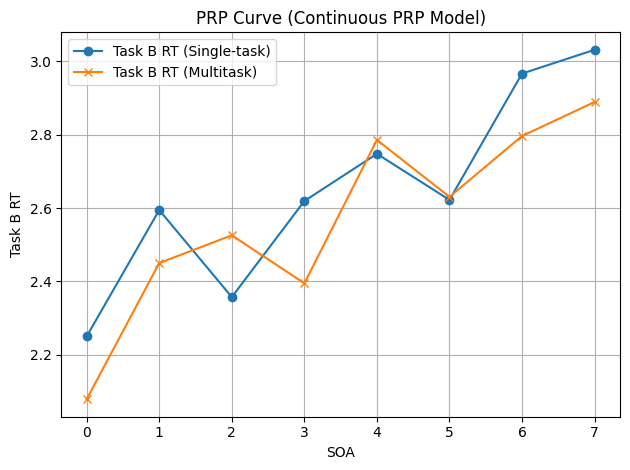

In [ ]:
# Single vs. Multi-task RT comparison

plt.plot(results_single["soa"], results_single["rt_b"], label="Task B RT (Single-task)", marker='o')
plt.plot(results_multi["soa"], results_multi["rt_b"], label="Task B RT (Multitask)", marker='x')
plt.xlabel("SOA")
plt.ylabel("Task B RT")
plt.title("PRP Curve (Continuous PRP Model)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


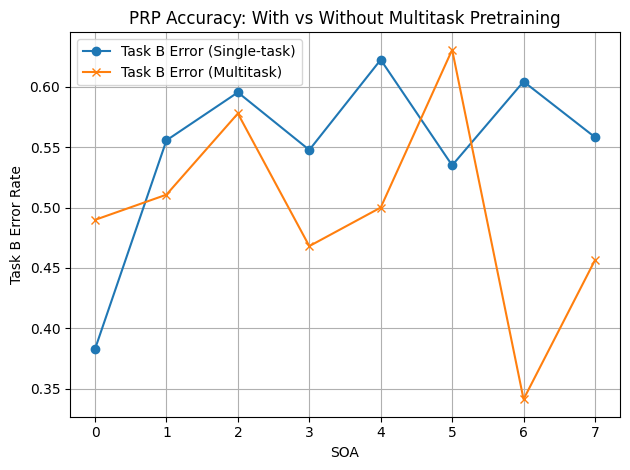

In [ ]:
# Single vs. Multi-task accuracy (error rate) comparison 

err_single = [1 - b if not np.isnan(b) else np.nan for b in results_single["acc_b"]]
err_multi = [1 - b if not np.isnan(b) else np.nan for b in results_multi["acc_b"]]

plt.plot(results_single["soa"], err_single, label="Task B Error (Single-task)", marker='o')
plt.plot(results_multi["soa"], err_multi, label="Task B Error (Multitask)", marker='x')
plt.xlabel("SOA")
plt.ylabel("Task B Error Rate")
plt.title("PRP Accuracy: With vs Without Multitask Pretraining")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

net_multi.model.eval()

# Same stimulus
stim_input = np.zeros(9)
stim_input[[0, 4, 8]] = 1  # e.g., one active per input dim

# Task A: task_id = 1 → input 1 → output 1
# Task B: task_id = 2 → input 1 → output 2
task_vec_1 = np.zeros(9)
task_vec_1[0] = 1
task_vec_2 = np.zeros(9)
task_vec_2[1] = 1

s = torch.tensor(stim_input, dtype=torch.float32).unsqueeze(0)
t1 = torch.tensor(task_vec_1, dtype=torch.float32).unsqueeze(0)
t2 = torch.tensor(task_vec_2, dtype=torch.float32).unsqueeze(0)

tau_net = 1.0

# Hidden activations
h1 = net_multi.model.activation_fn(
    net_multi.model.fc_input_to_hidden(torch.cat([s, t1], dim=1)) +
    tau_net * net_multi.model.task_to_hidden(t1)
).detach().numpy()

h2 = net_multi.model.activation_fn(
    net_multi.model.fc_input_to_hidden(torch.cat([s, t2], dim=1)) +
    tau_net * net_multi.model.task_to_hidden(t2)
).detach().numpy()


In [ ]:
similarity = cosine_similarity(h1, h2)[0, 0]
print(f"Cosine similarity between hidden representations: {similarity:.3f}")


Cosine similarity between hidden representations: 0.550


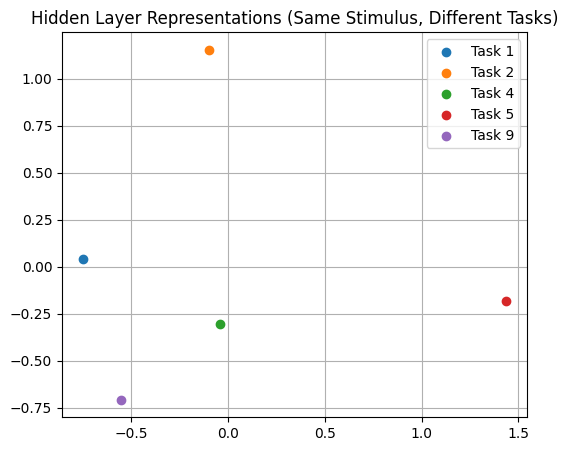

In [ ]:
# Generate activations for all tasks on same stimulus
hidden_acts = []
labels = []

for task_id in [1, 2, 4, 5, 9]:
    task_vec = np.zeros(9)
    task_vec[task_id - 1] = 1
    t = torch.tensor(task_vec, dtype=torch.float32).unsqueeze(0)
    h = net_multi.model.activation_fn(
        net_multi.model.fc_input_to_hidden(torch.cat([s, t], dim=1)) +
        tau_net * net_multi.model.task_to_hidden(t)
    ).detach().numpy()
    hidden_acts.append(h[0])
    labels.append(f"Task {task_id}")

# Visualize with PCA
pca = PCA(n_components=2)
hidden_2d = pca.fit_transform(np.array(hidden_acts))

plt.figure(figsize=(6, 5))
for i, label in enumerate(labels):
    plt.scatter(hidden_2d[i, 0], hidden_2d[i, 1], label=label)
plt.title("Hidden Layer Representations (Same Stimulus, Different Tasks)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
results_persist = sweep_soa(
    task_net=net,
    trial_generator=simple_trial_generator,
    soa_values=list(range(0, 8)),
    n_trials_per_soa=50,
    threshold=1.0,
    tau_net=1.0,
    tau_task=1.0,
    persistence=0.5,
    verbose=True
)


SOA 0 | RT_A: 1.30 | RT_B: 1.34
SOA 1 | RT_A: 1.43 | RT_B: 1.47
SOA 2 | RT_A: 1.46 | RT_B: 1.63
SOA 3 | RT_A: 1.60 | RT_B: 1.79
SOA 4 | RT_A: 1.82 | RT_B: 2.04
SOA 5 | RT_A: 1.81 | RT_B: 2.01
SOA 6 | RT_A: 1.83 | RT_B: 2.16
SOA 7 | RT_A: 1.65 | RT_B: 2.09


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_task_b_activations(task_net, trial_generator, soa_values, max_timesteps=50, tau_net=1.0, tau_task=1.0):
    # Use one fixed trial to eliminate variability
    input_a, input_b, task_a, task_b = trial_generator()

    # Get Task B output indices
    N_pathways = 3
    N_features = 3
    task_matrix_b = task_b.reshape(N_pathways, N_pathways).T
    in_dim_b, out_dim_b = np.argwhere(task_matrix_b == 1)[0]
    relevant_outputs_b = list(range(out_dim_b * N_features, (out_dim_b + 1) * N_features))

    plt.figure(figsize=(10, 6))
    for soa in soa_values:
        # Generate input series with current SOA
        input_dim = input_a.shape[0]
        task_dim = task_a.shape[0]
        input_series = []
        task_series = []

        for t in range(max_timesteps):
            stim_t = np.zeros(input_dim)
            task_t = np.zeros(task_dim)

            if t >= 0:
                stim_t += input_a
                task_t += task_a

            if t >= soa:
                stim_t += input_b
                task_t += task_b

            input_series.append(stim_t)
            task_series.append(task_t)

        # Forward pass
        output_series = task_net.integrate(input_series, task_series,
                                           tau_net=tau_net, tau_task=tau_task)

        # Extract relevant Task B output over time
        task_b_activations = [output[relevant_outputs_b].mean() for output in output_series]
        plt.plot(task_b_activations, label=f"SOA = {soa}")

    plt.xlabel("Time Step")
    plt.ylabel("Mean Activation (Task B Output Units)")
    plt.title("Task B Output Activation Over Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


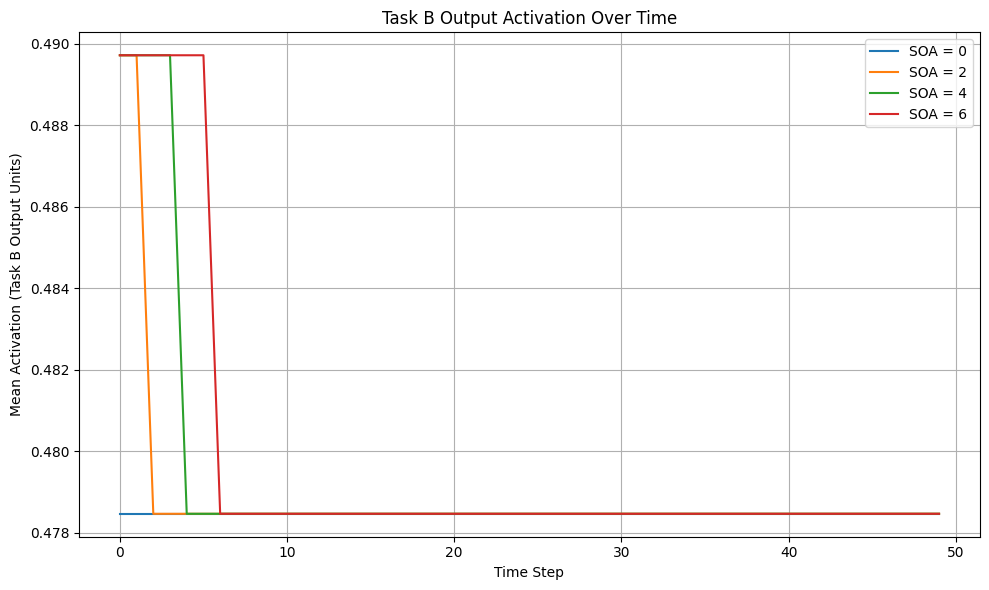

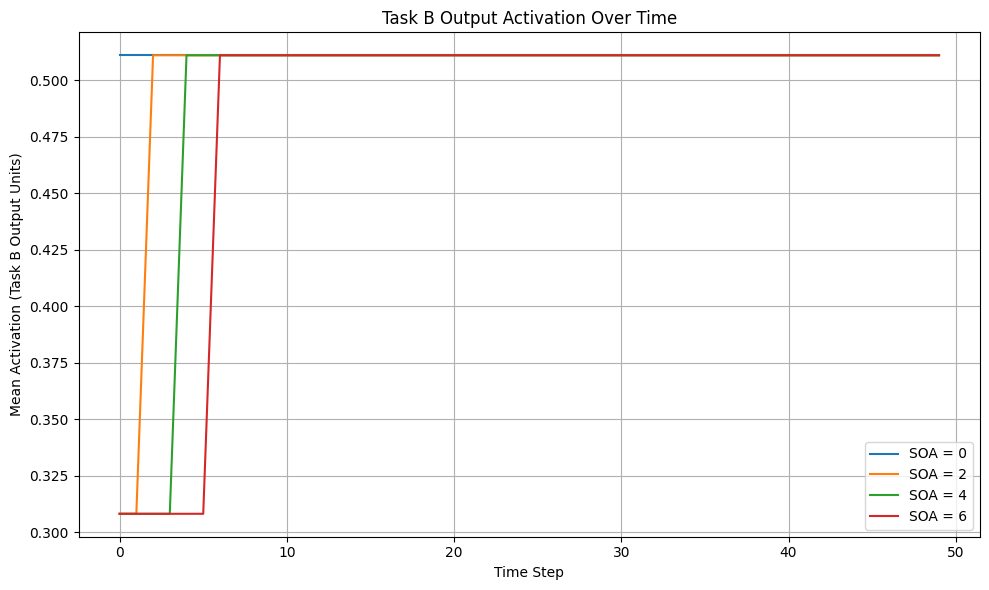

In [ ]:
visualize_task_b_activations(
    task_net=net,
    trial_generator=simple_trial_generator,  # replace with your generator
    soa_values=[0, 2, 4, 6],  # or range(0, 8)
    max_timesteps=50,
    tau_net=1.0,
    tau_task=1.0
)


In [ ]:
def visualize_task_b_units(task_net, trial_generator, soa_values, max_timesteps=50, tau_net=1.0, tau_task=1.0):
    input_a, input_b, task_a, task_b = trial_generator()

    N_pathways = 3
    N_features = 3
    task_matrix_b = task_b.reshape(N_pathways, N_pathways).T
    in_dim_b, out_dim_b = np.argwhere(task_matrix_b == 1)[0]
    relevant_outputs_b = list(range(out_dim_b * N_features, (out_dim_b + 1) * N_features))

    plt.figure(figsize=(10, 6))
    for soa in soa_values:
        input_series = []
        task_series = []

        for t in range(max_timesteps):
            stim_t = np.zeros_like(input_a)
            task_t = np.zeros_like(task_a)

            if t >= 0:
                stim_t += input_a
                task_t += task_a

            if t >= soa:
                stim_t += input_b
                task_t += task_b

            input_series.append(stim_t)
            task_series.append(task_t)

        output_series = task_net.integrate(input_series, task_series,
                                           tau_net=tau_net, tau_task=tau_task)

        output_matrix = np.array([out[relevant_outputs_b] for out in output_series])
        for i in range(3):
            plt.plot(output_matrix[:, i], label=f"SOA={soa} | Unit {i}")

    plt.xlabel("Time Step")
    plt.ylabel("Activation")
    plt.title("Task B Output Units Over Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


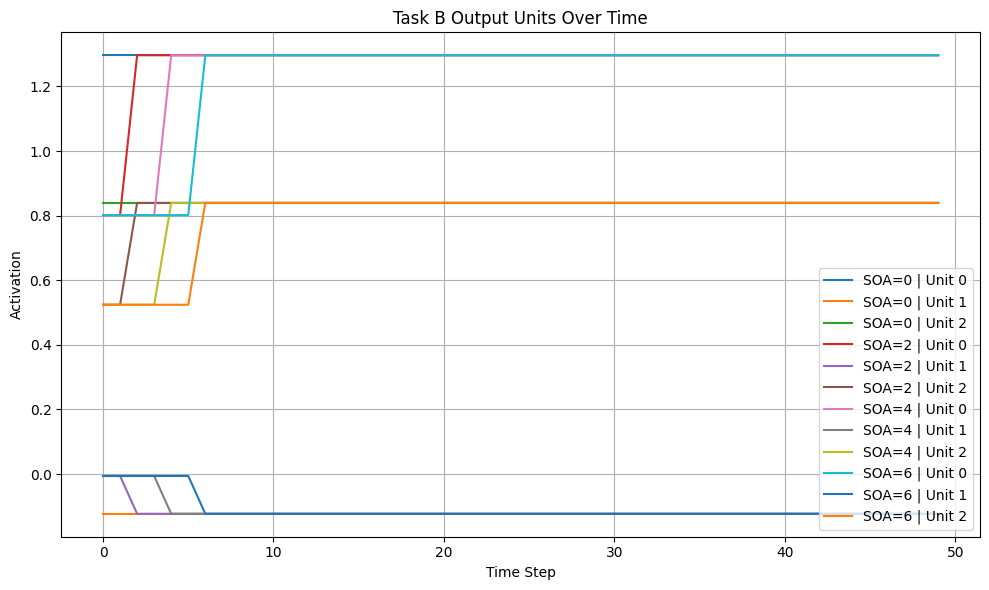

In [ ]:
visualize_task_b_units(
    task_net=net,  # your trained TaskNetworkWrapper instance
    trial_generator=simple_trial_generator,  # your trial generator function
    soa_values=[0, 2, 4, 6],  # adjust as needed
    max_timesteps=50,
    tau_net=1.0,
    tau_task=1.0
)
